# A Machine learning perspective on predicting loan default risks in financial services

Understanding and predicting loan defaults is crucial for financial institutions to manage risk effectively. Accurate predictions can help in making informed lending decisions, reducing the occurrence of bad debts, and ensuring financial stability. Also by performing machine learning, lenders can refine their criteria for approving loans, ensuring that they are lending to individuals and businesses with a lower risk of default. This can lead to more responsible lending practices and a healthier credit market.

Data set used for the research: https://www.kaggle.com/datasets/anubhavyadavbca2025/lending-page-loan-dataset

The data set is from Lending club during 2007 to 2010.

## Understanding the data set

In [ ]:
import pandas as pd

df = pd.read_csv('loan_data.csv')

# Display first 5 rows of the data
print(df.head())

   credit.policy             purpose  int.rate  installment  log.annual.inc  \
0              1  debt_consolidation    0.1189       829.10       11.350407   
1              1         credit_card    0.1071       228.22       11.082143   
2              1  debt_consolidation    0.1357       366.86       10.373491   
3              1  debt_consolidation    0.1008       162.34       11.350407   
4              1         credit_card    0.1426       102.92       11.299732   

     dti  fico  days.with.cr.line  revol.bal  revol.util  inq.last.6mths  \
0  19.48   737        5639.958333      28854        52.1               0   
1  14.29   707        2760.000000      33623        76.7               0   
2  11.63   682        4710.000000       3511        25.6               1   
3   8.10   712        2699.958333      33667        73.2               1   
4  14.97   667        4066.000000       4740        39.5               0   

   delinq.2yrs  pub.rec  not.fully.paid  
0            0        0   

In [ ]:
# Show the names of the columns
colnam = df.columns

for x in colnam:
    print(f'Colume name: {x}')

Colume name: credit.policy
Colume name: purpose
Colume name: int.rate
Colume name: installment
Colume name: log.annual.inc
Colume name: dti
Colume name: fico
Colume name: days.with.cr.line
Colume name: revol.bal
Colume name: revol.util
Colume name: inq.last.6mths
Colume name: delinq.2yrs
Colume name: pub.rec
Colume name: not.fully.paid


In [3]:
# Show the dimensions of the data
df.shape

(9578, 14)

Here is a detail description of the columns:

1. **credit.policy:** whether the borrower met LendingClub’s underwriting criteria (binary).

2. **purpose:** categorical reason for the loan (e.g. credit_card, debt_consolidation, etc.).

3. **int.rate:** loan interest rate (as a decimal).

4. **installment:** monthly payment amount.

5. **log.annual.inc:** log of borrower’s self-reported annual income.

6. **dti:** debt-to-income ratio.

7. **fico:** FICO credit score.

8. **days.with.cr.line:** tenure of credit history in days.

9. **revol.bal:** revolving credit balance.

10. **revol.util:** percent of revolving credit used.

11. **inq.last.6mths:** number of credit inquiries in the last six months.

12. **delinq.2yrs:** number of 30+ day delinquencies in past two years.

13. **pub.rec:** number of derogatory public records.

14. **not.fully.paid:** target variable (1 if loan was not fully paid, 0 otherwise).

And from the dimensions of the data, we see that it has 9578 number of rows.

## Checking for NAs and duplicates in the data

In [4]:
# Count the number of NAs in each columns
print('The number of NAs in the data set categorized by columns are: \n', df.isnull().sum())

The number of NAs in the data set categorized by columns are: 
 credit.policy        0
purpose              0
int.rate             0
installment          0
log.annual.inc       0
dti                  0
fico                 0
days.with.cr.line    0
revol.bal            0
revol.util           0
inq.last.6mths       0
delinq.2yrs          0
pub.rec              0
not.fully.paid       0
dtype: int64


In [5]:
# Count the number of duplicated rows
print('The total number of duplicated rows in the data set is:', df.duplicated().sum())

The total number of duplicated rows in the data set is: 0


As we see from the results above, we do not have duplicated values and missing values in the data set. This is very good

## Explore the data set

In [6]:
import matplotlib.pyplot as plt

### Investigate the numeric features of this data set

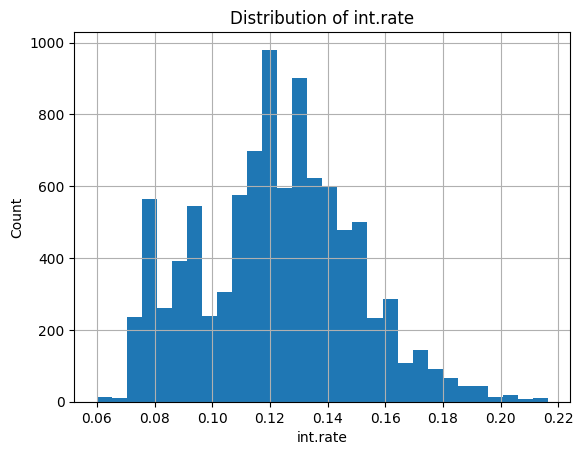

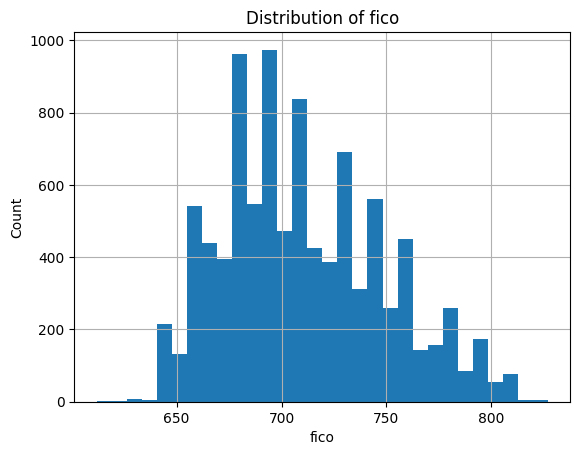

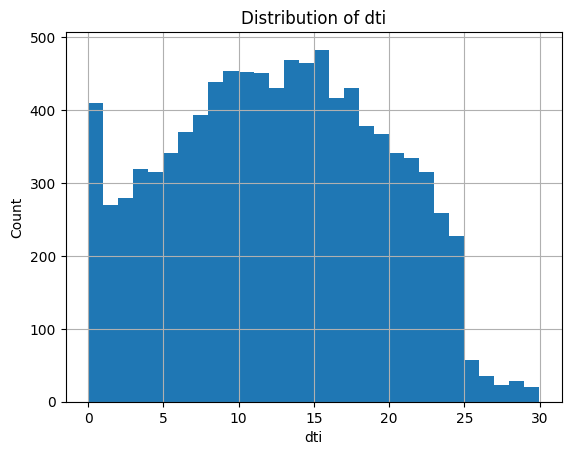

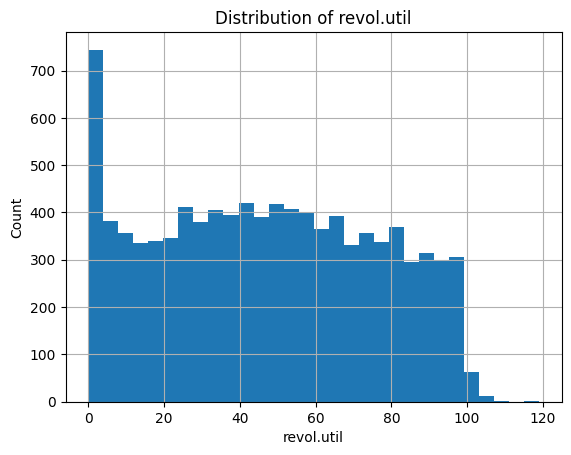

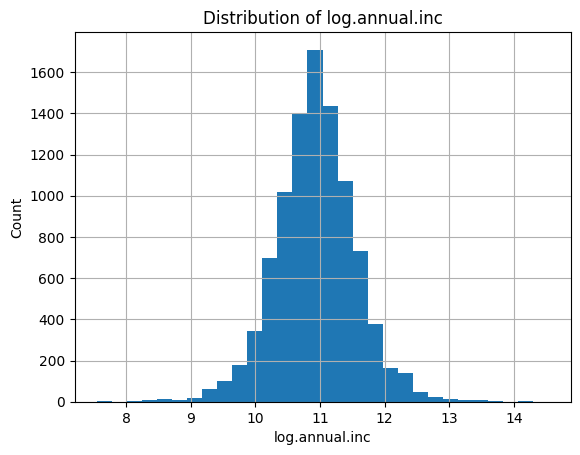

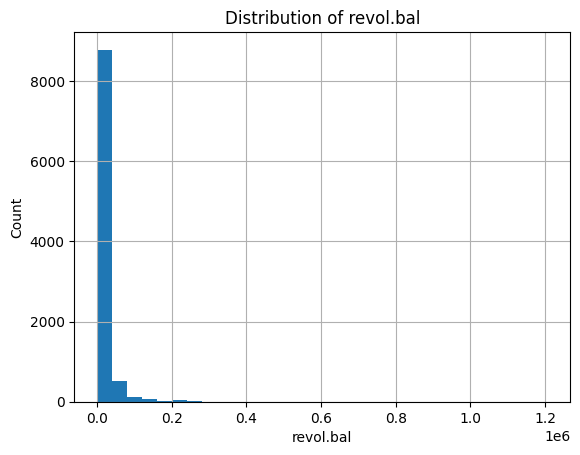

In [ ]:
# List of numeric features to visualize
features = ['int.rate', 'fico', 'dti', 'revol.util', 'log.annual.inc', 'revol.bal']

for feat in features:
    plt.figure()
    df[feat].hist(bins=30)
    plt.title(f'Distribution of {feat}')
    plt.xlabel(feat)
    plt.ylabel('Count')
    plt.show()

1. The interest‐rate histogram is roughly bell‐shaped but slightly right‐skewed. Most loans cluster between about $0.10$ and $0.15$ ($10–15\%$), indicating LendingClub charges the bulk of borrowers in that mid‐range, with fewer extreme low or high rates.

2. FICO scores form an approximately normal distribution centered around $700–720$, with very few borrowers below $650$ or above $800$. This suggests most applicants meet reasonably good credit thresholds, and extremes are rare.

3. Most borrowers carry debt equal to about $10–15\%$ of their income, which is probably far from underwriting caps. The small spike at zero likely indicates some borrowers report no other debt. A minority have DTI approaching or exceeding common limits, means these are higher-stress borrowers.

4. In terms of revolving credit utilization, many borrowers keep balances low relative to their total credit, which means a good credit hygiene. While a large middle group is carrying moderate balances; they’re using their cards but not maxing them out. However, over-limit usage is rare but a red flag when it occurs.

5. Most borrowers report annual incomes between roughly $40k and $100k. The few extreme lows or highs suggests borrower pool is middle-income; outliers below $30k or above $150k are uncommon.

6. Most revolving balances are under $\$10000$, but a small number exceed $\$200000$. These high balances are likely business owners or people with large credit lines, and they carry very different risk profiles.

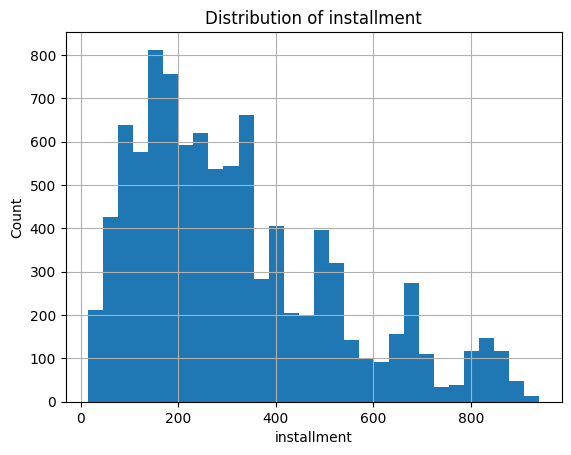

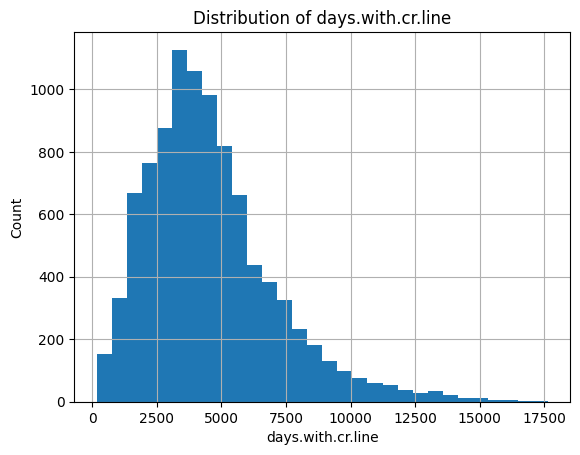

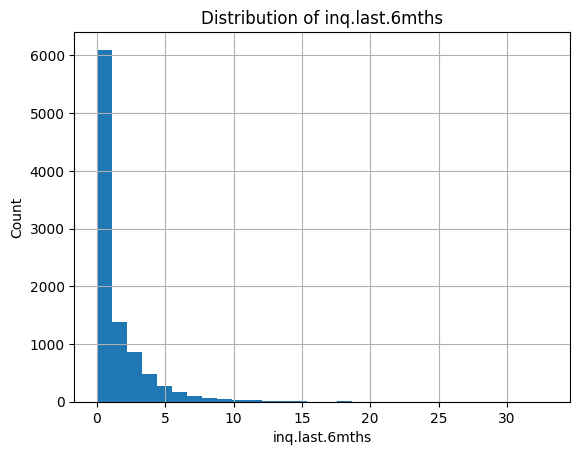

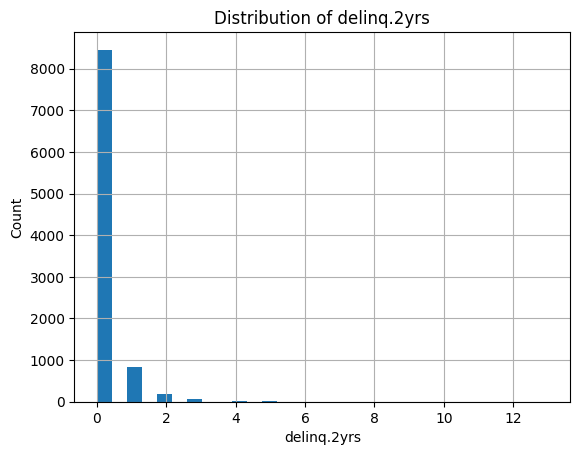

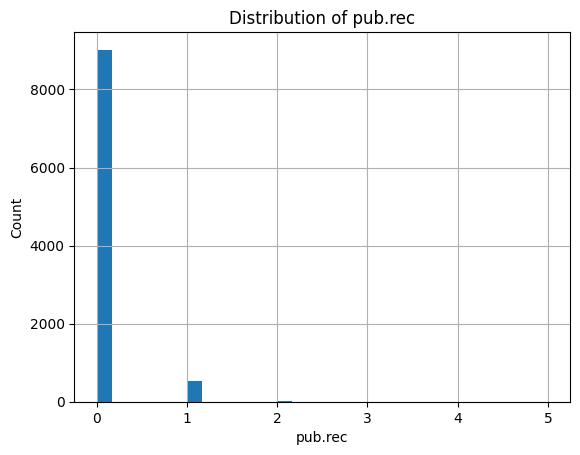

In [8]:
# Other numeric features
other_feats = ['installment', 'days.with.cr.line', 'inq.last.6mths', 'delinq.2yrs', 'pub.rec']

for feat in other_feats:
    plt.figure()
    df[feat].hist(bins=30)
    plt.title(f'Distribution of {feat}')
    plt.xlabel(feat)
    plt.ylabel('Count')
    plt.show()

1. For the installment, it ranges roughly $30–$900 per month, with most between $100–$400. Installment size reflects both loan amount and term. Higher installments (relative to income) can stress budgets. A borrower paying $800 per month is at greater risk than one paying $150 per month, especially if their income is similar.

2. Most people in the data set has a credit line age of $2000$ to $6000$ days ($\approx 5 \sim 16$ years), with a tail out to $17000$ days ($ \approx 47$ years). Longer credit histories generally correlate with lower default rates, as they demonstrate established credit behavior.

3. Majority of the people in the data set have $0 \sim 1$ inquiries in the last $6$ months; very few exceed $5$. High inquiry counts signal credit shopping or distress.

4. When it comes to delinquencies in past $2$ years, Most have zero; small spikes at $1$ or $2$ delinquencies; very few have larger than $3$. And any prior delinquency is a red flag.

5. Over $90\%$ have zero derogatory public records; $ \sim 5\%$ have one; almost none have more. 

### Other categorical features

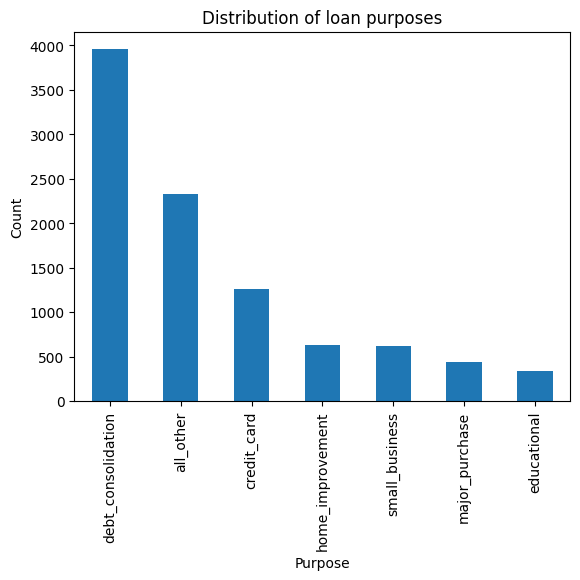

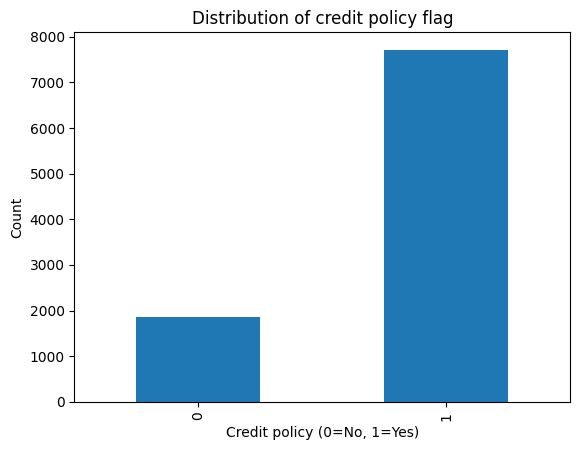

In [9]:
# Categorical features: purpose and credit.policy
plt.figure()
df['purpose'].value_counts().plot(kind='bar')
plt.title('Distribution of loan purposes')
plt.xlabel('Purpose')
plt.ylabel('Count')
plt.show()

plt.figure()
df['credit.policy'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution of credit policy flag')
plt.xlabel('Credit policy (0=No, 1=Yes)')
plt.ylabel('Count')
plt.show()

1. In terms of the purpose of the loan, most borrowers are consolidating existing debt or small loans, reflecting a common use case of peer‐to‐peer lending. “all_other” lumps miscellaneous uses, and credit‐card refinancing is also sizable.

2. over $80\%$ meet LendingClub’s own underwriting policy, while about $20\%$ do not.

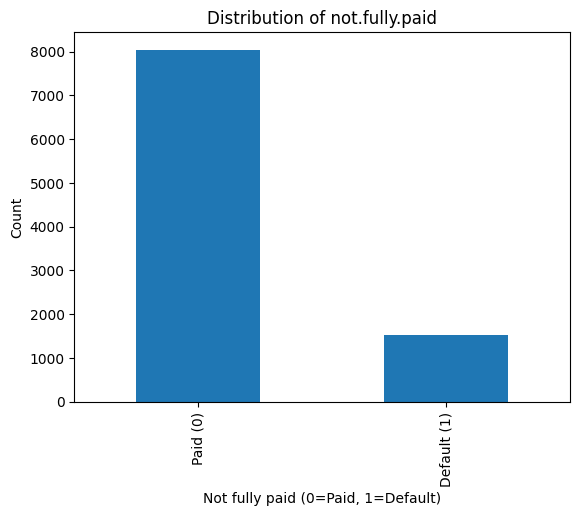

In [10]:
plt.figure()
df['not.fully.paid'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution of not.fully.paid')
plt.xlabel('Not fully paid (0=Paid, 1=Default)')
plt.ylabel('Count')
plt.xticks([0,1], ['Paid (0)', 'Default (1)'])
plt.show()

We can see that the data set is not balanced. This will impact our modeling approach. And we need to consider more stuff.

### Exam the correlation

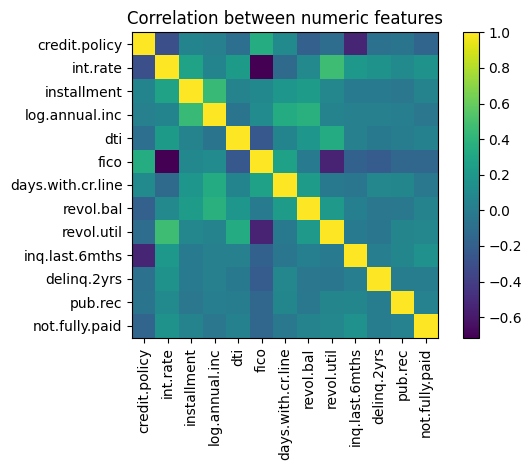

In [ ]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

corr_matrix = numeric_df.corr()

plt.figure()
plt.imshow(corr_matrix, interpolation='nearest')
plt.title('Correlation between numeric features')
plt.xticks(range(len(corr_matrix)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix)), corr_matrix.columns)
plt.colorbar()
plt.tight_layout()
plt.show()

1. Borrowers with higher FICO scores receive lower interest rates.

2. Better credit scores coincide with lower revolving credit utilization.

3. Loans meeting LendingClub’s policy criteria tend to have fewer recent inquiries.

4. Most other pairings sit below $|0.4|$, indicating relatively independent.

5. The largest absolute correlations to the target are modest, confirming defaults are multifactorial.

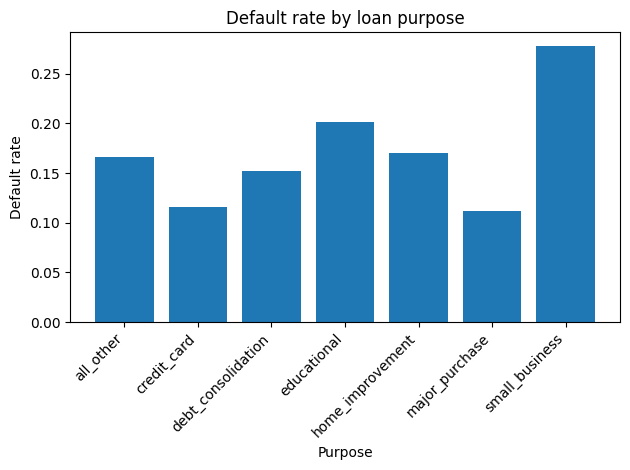

In [12]:
# Default rates by loan purpose
purpose_group = df.groupby('purpose')['not.fully.paid'].agg(['count', 'sum'])
purpose_group['default_rate'] = purpose_group['sum'] / purpose_group['count']

purpose_rates = purpose_group.reset_index().rename(columns={
    'count': 'total_loans',
    'sum': 'num_defaults'
})

plt.figure()
plt.bar(purpose_rates['purpose'], purpose_rates['default_rate'])
plt.title('Default rate by loan purpose')
plt.xlabel('Purpose')
plt.ylabel('Default rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

1. Small business has the highest default rate, likely due to variable cash flows and business failures.

2. Educational e.g. student loan borrowers likely have lower incomes, elevating their default likelihood.

3. major_purchase and credit_card are likely backed by planned spending and repayment, leading to stronger repayment probability.

## Constructing the model

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [ ]:
df_encoded = pd.get_dummies(df, columns=['purpose'], drop_first=True)

X = df_encoded.drop('not.fully.paid', axis=1)
y = df_encoded['not.fully.paid']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=123, stratify=y
)

# Train the model
model = RandomForestClassifier(
    random_state=123,
    class_weight='balanced'
)

model.fit(X_train, y_train)

model

RandomForestClassifier(class_weight='balanced', random_state=123)

Our data contains both continuous predictors and a one-hot encoded categorical feature (purpose). Random Forests naturally handle mixtures of variable types and capture non-linear interactions without requiring manual feature transformations or interaction terms. In addition, several features are heavily skewed and contain extreme values. Tree-based methods aren’t impacted by outliers the way linear models do, so, they don’t require standardizing or normalizing inputs, thus simplifying the preprocessing.

By setting class_weight='balanced', the algorithm automatically adjusts the weight of the minority class (defaults) so that it is favored more often during training.

### Checking the performance of the model

In [15]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn import metrics

In [16]:
# Predictions on the test set
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

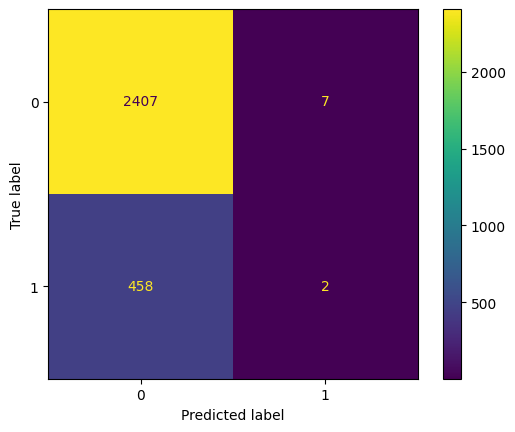

In [17]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = cm)
cm_display.plot()
plt.show()

From the matrix, out of 460 actual defaults, only 2 were caught (recall ≈ 0.004), while 458 slipped through.

In [18]:
# Classification report
cr_dict = classification_report(y_test, y_pred)
print(cr_dict)

              precision    recall  f1-score   support

           0       0.84      1.00      0.91      2414
           1       0.22      0.00      0.01       460

    accuracy                           0.84      2874
   macro avg       0.53      0.50      0.46      2874
weighted avg       0.74      0.84      0.77      2874



From the classification report, class 0 (Paid) has precision 0.84, it almost perfectly identifies non-defaults. However, class 1 (Default) has precision 0.22, it hardly identifies any of the true defaults.

Macro-averages around 0.5 reflect the huge imbalance between classes.

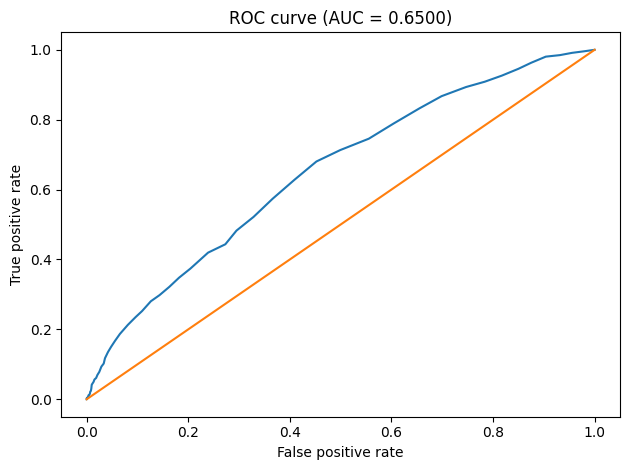

In [19]:
# ROC AUC
auc_score = roc_auc_score(y_test, y_proba)
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1])
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title(f'ROC curve (AUC = {auc_score:.4f})')
plt.tight_layout()
plt.show()

AUC ≈ 0.65 suggests the model does have some ability to rank defaults above non-defaults (better than random).

## Improving the model

In [20]:
from sklearn.utils import resample

In [21]:
# Combine X_train and y_train for oversampling
train_df = pd.concat([X_train, y_train], axis=1)
majority = train_df[train_df['not.fully.paid'] == 0]
minority = train_df[train_df['not.fully.paid'] == 1]

# Oversample the minority class to match the majority count
minority_oversampled = resample(
    minority,
    replace=True,
    n_samples=len(majority),
    random_state=123
)

train_balanced = pd.concat([majority, minority_oversampled])
X_train_bal = train_balanced.drop('not.fully.paid', axis=1)
y_train_bal = train_balanced['not.fully.paid']

improved_model = RandomForestClassifier(
    n_estimators=200,
    min_samples_leaf=5,
    random_state=123
)
improved_model.fit(X_train_bal, y_train_bal)

improved_model

RandomForestClassifier(min_samples_leaf=5, n_estimators=200, random_state=123)

In [22]:
# Predictions on the test set
y_pred = improved_model.predict(X_test)
y_proba = improved_model.predict_proba(X_test)[:, 1]

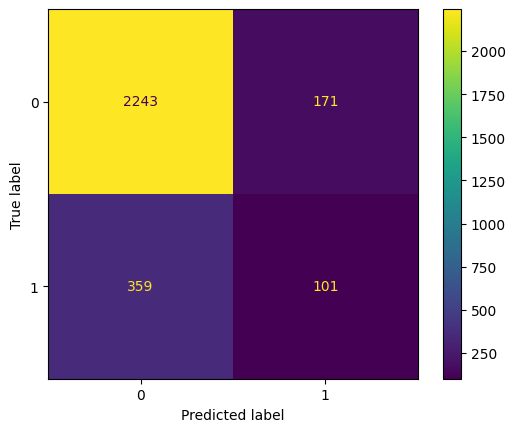

In [23]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = cm)
cm_display.plot()
plt.show()

In [24]:
# Classification report
cr_dict = classification_report(y_test, y_pred)
print(cr_dict)

              precision    recall  f1-score   support

           0       0.86      0.93      0.89      2414
           1       0.37      0.22      0.28       460

    accuracy                           0.82      2874
   macro avg       0.62      0.57      0.59      2874
weighted avg       0.78      0.82      0.80      2874



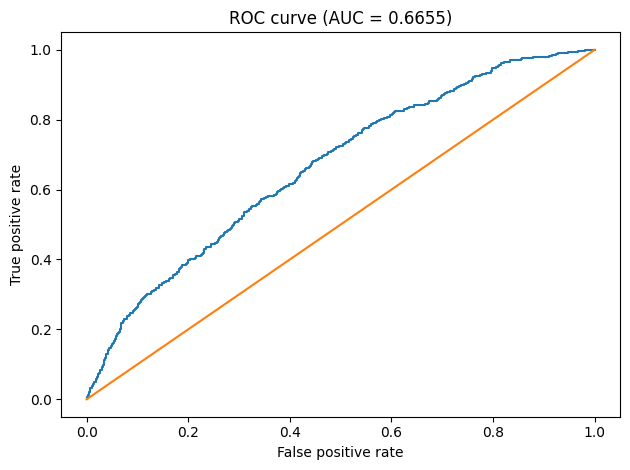

In [25]:
# ROC AUC
auc_score = roc_auc_score(y_test, y_proba)
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1])
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title(f'ROC curve (AUC = {auc_score:.4f})')
plt.tight_layout()
plt.show()

From the confusion matrix, classification report, and the AUC, we can see that the model is now performing better by oversampling the default class and tuned the Random Forest (increased trees & added a minimum‐leaf constraint). But the model still struggles to balance catching defaults against false rejects.

## Conclusion and future work

In this project, we used the LendingClub data (2007–2010) to build a predictive model for loan default (not.fully.paid). We constructed a Random Forest classifier, first on the imbalanced data and then on a rebalanced training set via oversampling. While the baseline model nearly ignored defaults, our improved model captured roughly 22% of actual defaults, and increase AUC from 0.65 to 0.67. This demonstrates both the predictive signal in the features and the importance of addressing class imbalance. In the future, similar work can be done with a more recent and balanced data set that is publically avaliable.